# Plot Hi-C Image to Estimate Jet Widths

In [1]:
%matplotlib widget 
# Important that you have interactive widgets to estimate the jet widths using the cursor

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os

import sys
sys.path.append('..')
from miajet.hic_image import compute_rm_idx, clip_and_normalize, rotate_stack_extract_rectangle
from utils.processing import read_hic_file, whiten_matrix, save_histogram
from utils.scale_space import generate_scales_from_widths, scale_to_width, clip_scale_range

def generate_hic_only(hic_file, chromosome, resolution, window_size, data_type, normalization, whiten,
                        rotation_padding, save_path, verbose, root,
                        im_vmax_perc, im_vmin_perc, corner_vmax_perc, corner_vmin_perc):
    """
    Variant of `generate_hic_bundle` from miajet v1.0.27
    Should be identical to `im`
    """
    save_name = None
    if save_path is not None:
        save_name = os.path.join(save_path, f"{root}_contact_map.jpg")

    window_size_bin = np.ceil(window_size / resolution).astype(int)

    # Single access via hic-straw (observed only)
    mat_obs = read_hic_file(filename=hic_file, chrom=chromosome, resolution=resolution,
                            positions="all", data_type="observed", normalization=normalization, verbose=verbose)

    if mat_obs.shape == (1, 1):
        raise ValueError(f".hic file read in error. This is most likely due to the normalization vectors not being present in the .hic file. "
                         f"Suggestion: retry with a different normalization method than '{normalization}'")

    mat_obs = mat_obs.astype(np.float32)

    # Fill nans with 0
    mat_obs[np.isnan(mat_obs)] = 0

    # Determine the common removed indices 
    rm_idx = compute_rm_idx(mat_obs, window_size_bin, verbose=verbose)
    mat_obs_sub = np.delete(np.delete(mat_obs, rm_idx, axis=0), rm_idx, axis=1)

    if mat_obs_sub.shape[0] == 0 or mat_obs_sub.shape[1] == 0:
        raise ValueError(f"Empty contact map generated for chromosome {chromosome} with resolution {resolution} and window size {window_size}. "
                         f"Please check the Hi-C file {hic_file} for coverage and/or parameters")

    # IMAGE
    im_sq = np.log10(mat_obs_sub + 1)
    if whiten is not None:
        # If not None, then interpret the `whiten` parameter as the epsilon parameter
        im_sq = cv.normalize(im_sq, None, alpha=0, beta=1, norm_type=cv.NORM_MINMAX, dtype=cv.CV_32F)
        im_sq, _ = whiten_matrix(A_for_corr=im_sq, A_for_whiten=im_sq, epsilon=whiten)

    im_sq = clip_and_normalize(im_sq, im_vmin_perc, im_vmax_perc)

    # ROTATION CODE
    # Some basic statistics for the rotation code
    N = im_sq.shape[0]
    window_size_bin_rect = np.ceil(window_size_bin / np.sqrt(2)).astype(int)
    center = np.ceil(N * np.sqrt(2) / 2).astype(int)

    # Single rotation with only the image stacked
    mats_to_rotate = [im_sq]
    rot_list = rotate_stack_extract_rectangle(mats_to_rotate, rotate_mode=rotation_padding, cval=0, 
                                              center=center, window_size_bin_rect=window_size_bin_rect)
    im, = rot_list

    # Save statistics histogram for the IMAGE only
    if save_path is not None:
        plt.imsave(save_name, im, cmap="gray", vmax=np.percentile(im, im_vmax_perc), vmin=np.percentile(im, im_vmin_perc))
        save_histogram(im, save_path, file_name=f"{root}_contact_map_intensity_value_histogram.jpg", vmin_perc=im_vmin_perc, vmax_perc=im_vmax_perc)

    return im


In [ ]:
hic_file = "/nfs/turbo/umms-minjilab/downloaded_data/c-elegans-JK06-L3_WAPL-auxin-1hr_hic_Kim-2023_GSE237663_ce10.hic"
chrom = "chrI"
resolution = int(2e3)
window_size = int(300000)
normalization = "KR"
data_type = "oe"

In [7]:
# Generate Hi-C rectangle
im = generate_hic_only(hic_file=hic_file, 
                             chromosome=chrom, resolution=resolution, window_size=window_size, data_type=data_type, normalization=normalization, 
                             whiten=None, rotation_padding="nearest", verbose=True, 
                             im_vmax_perc=100, im_vmin_perc=0, corner_vmax_perc=100, corner_vmin_perc=0, root="",
                             save_path=None, # Or you can specify a path to save the contact map to load into another program 
                             )

Identified
Possible resolutions
 * 80000
 * 40000
 * 20000
 * 15000
 * 10000
 * 5000
 * 3000
 * 2000
 * 1000
 * 500
Chrom name : Chrom size:
  - ALL 100272
  - I 15072423 <- Selected
  - II 15279345
  - III 13783700
  - IV 17493793
  - V 20924149
  - X 17718866
(7537, 7537) -> (7473, 7473)
    Removed indices: [ 112  122  560  878 1019 1983 1986 2141 2142 2143 2144 2145 2146 2171
 2172 2173 2174 2175 2176 2177 2271 3889 3891 3922 4310 5103 5104 5105
 5106 5107 5134 5137 5426 5651 5654 5725 5726 5734 5735 5808 5809 5812
 6068 6070 6130 6134 6135 6314 6315 6318 6319 6703 6728 6805 6806 6870
 6946 7150 7152 7443 7444 7531 7534 7535]


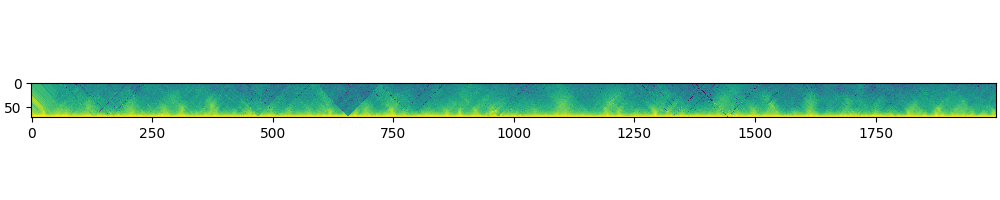

In [13]:
plt.close()
plt.figure(figsize=(10, 2), layout="constrained")
plt.imshow(im[:, :2000], cmap="viridis", interpolation="none", vmax=np.percentile(im, 96), vmin=0)
plt.show()

Zoom in with box. Hover mouse to see the pixels and estimate jet widths lower bound and upper bound

In [16]:
# Set jet width lower bound and upper bound estimates here
w0 = 3
w1 = 50

# Then you can see if any scale will be clipped (so you can increase window_size)
# Set of scales that MIA-Jet will generate
S = generate_scales_from_widths(w0=w0, w1=w1, base=1.5, scale_resolution=0.25)

# Any clipping that occurs. If no clipping occurs, the current parameter setting is fine!
S_final = clip_scale_range(scale_range=S, im_shape=im.shape, verbose=False)

if len(S_final) != len(S):
    print()
    w0_final = scale_to_width(S_final.min())
    w1_final = scale_to_width(S_final.max())
    print(f"With the current settings, you can only detect jet widths {w0_final:.3f} to {w1_final:.3f} pixels")
    print(f'To detect the full range of jet widths that you have specified {w0:.3f} to {w1:.3f} try to increase the window size or the resolution')
else:
    print(f"Final scale range: {[f'{s:.3f}' for s in S_final]}")
    print("Parameters seem fine!")

Final scale range: ['1.366', '1.516', '1.682', '1.866', '2.071', '2.298', '2.549', '2.829', '3.139', '3.483', '3.864', '4.288', '4.758', '5.279', '5.858', '6.499', '7.212', '8.002', '8.879', '9.852', '10.932', '12.130', '13.459', '14.934']
Parameters seem fine!


---

In [12]:
# hic_file = "/nfs/turbo/umms-minjilab/downloaded_data/zebrafish-embryo_sperm_hic_Wike-2021_4DNFI4P145EM_z11.hic"
hic_file = "/nfs/turbo/umms-minjilab/downloaded_data/zebrafish-embryo_sperm_hic_Wike-2021_4DNFI4P145EM_z11.ice_small_chr14_.hic"
chrom = "chr14"
resolution = int(50e3)
window_size = int(3000000)
normalization = "KR"
data_type = "oe"

In [14]:
# Generate Hi-C rectangle
im = generate_hic_only(hic_file=hic_file, 
                             chromosome=chrom, resolution=resolution, window_size=window_size, data_type=data_type, normalization=normalization, 
                             whiten=None, rotation_padding="nearest", verbose=True, 
                             im_vmax_perc=100, im_vmin_perc=0, corner_vmax_perc=100, corner_vmin_perc=0, root="",
                             save_path=None, # Or you can specify a path to save the contact map to load into another program 
                             )

Identified
Possible resolutions
 * 50000
Chrom name : Chrom size:
  - All 1679203
  - chr4 78093715
  - chr7 74282399
  - chr5 72500376
  - chr3 62628489
  - chr6 60270059
  - chr2 59640629
  - chr1 59578282
  - chr9 56459846
  - chr16 55266484
  - chr20 55201332
  - chr8 54304671
  - chr17 53461100
  - chr14 52660232 <- Selected
  - chr13 52186027
  - chr18 51023478
  - chr12 49182954
  - chr19 48449771
  - chr15 48040578
  - chr23 46223584
  - chr21 45934066
  - chr11 45484837
  - chr10 45420867
  - chr24 42172926
  - chr22 39133080
  - chr25 37502051
  - chr8_KZ115264v1_alt 976511
  - chr12_KZ115372v1_alt 937928
  - chr1_KZ114841v1_alt 865375
  - chr6_KZ115174v1_alt 809863
  - chr20_KZ115611v1_alt 770119
  - chr10_KZ115330v1_alt 761247
  - chr12_KZ114926v1_alt 750006
  - chr25_KZ115742v1_alt 719945
  - chr14_KZ115446v1_alt 716762
  - chr5_KZ115125v1_alt 705686
  - chr1_KZ114835v1_alt 679277
  - chr19_KZ115589v1_alt 670230
  - chr23_KZ115695v1_alt 663362
  - chr9_KZ115282v1_alt 65939

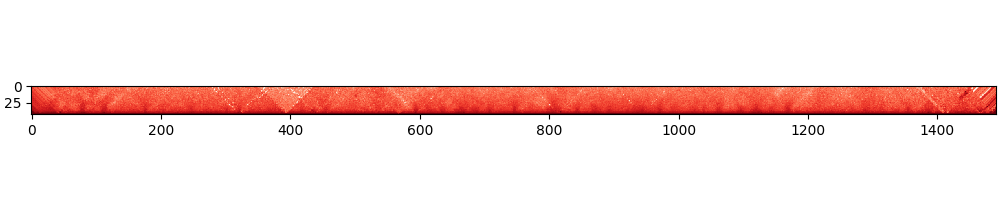

In [15]:
plt.close()
plt.figure(figsize=(10, 2), layout="constrained")
plt.imshow(im, cmap="Reds", interpolation="none", vmax=np.percentile(im, 96), vmin=0)
plt.show()

In [20]:
# Set jet width lower bound and upper bound estimates here
w0 = 5
w1 = 15

# Then you can see if any scale will be clipped (so you can increase window_size)
# Set of scales that MIA-Jet will generate
S = generate_scales_from_widths(w0=w0, w1=w1, base=1.5, scale_resolution=0.25)

# Any clipping that occurs. If no clipping occurs, the current parameter setting is fine!
S_final = clip_scale_range(scale_range=S, im_shape=im.shape, verbose=False)

if len(S_final) != len(S):
    print()
    w0_final = scale_to_width(S_final.min())
    w1_final = scale_to_width(S_final.max())
    print(f"With the current settings, you can only detect jet widths {w0_final:.3f} to {w1_final:.3f} pixels")
    print(f'To detect the full range of jet widths that you have specified {w0:.3f} to {w1:.3f} try to increase the window size')
else:
    print("Parameters seem fine!")

Parameters seem fine!
